Grid Search Best Guesses: Amplitude=2.5, Center=3.77, Sigma=1.48
Final Optimized Beam Center is 3.770 ± 0.014 cm.


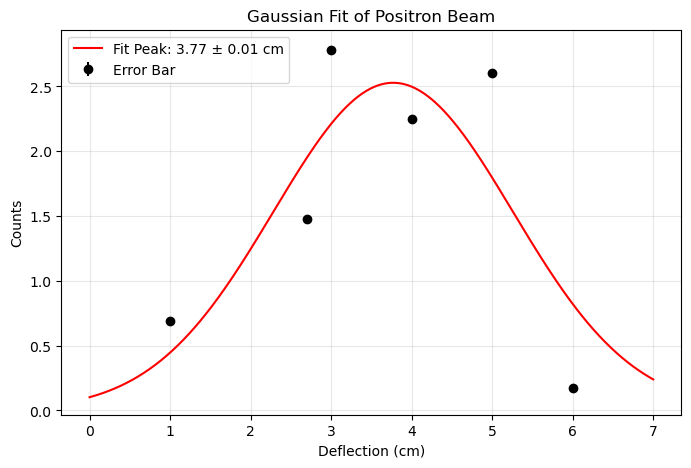

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import itertools # Added for the grid search loop

def load_and_clean(filename, skip=1):
    df = pd.read_csv(filename, encoding='latin-1', skiprows=skip)
    df = df.dropna(axis=1, how='all')
    df = df.dropna(subset=[df.columns[1]]) 
    new_names = ['time', 'CPM', 'error', 'Offset']
    df.columns = new_names[:len(df.columns)]
    df["counts"] = df["CPM"].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)
    return df

# --- Load the datasets ---
bg = load_and_clean("PH336_Background_Count_Data_2.7.csv", skip=5)
d1 = load_and_clean("PH336_Experiment_Count_Data_2.7.csv", skip=1)
d2 = load_and_clean("PH336_Experiment_Count_Data_3.0.csv", skip=1)
d3 = load_and_clean("PH336_Experiment_Count_Data_4.0.csv", skip=1)
d4 = load_and_clean("PH336_Experiment_Count_Data_1.0.csv", skip=1)
d5 = load_and_clean("PH336_Experiment_Count_Data_5.0.csv", skip=1)
d6 = load_and_clean("PH336_Experiment_Count_Data_6.0.csv", skip=1)

# Finding background by finding the minimum value across each set
bg_min = np.array([
    d4["counts"].min(),
    d1["counts"].min(),
    d2["counts"].min(),
    d3["counts"].min(),
    d5["counts"].min(),
    d6["counts"].min()]).min() # Fixed the duplicate d3 from original code

# Subtract background to get the TRUE positron signal
avg_4 = d4["counts"].mean() - bg_min
avg_1 = d1["counts"].mean() - bg_min
avg_2 = d2["counts"].mean() - bg_min
avg_3 = d3["counts"].mean() - bg_min
avg_5 = d5["counts"].mean() - bg_min
avg_6 = d6["counts"].mean() - bg_min

x_data = np.array([1.0, 2.7, 3.0, 4.0, 5.0, 6.0])
y_data = np.array([avg_4, avg_1, avg_2, avg_3, avg_5, avg_6])
y_err = np.array([
    d4["counts"].sem(),
    d1["counts"].sem(),
    d2["counts"].sem(),
    d3["counts"].sem(),
    d5["counts"].sem(),
    d5["counts"].sem()])

def gaussian(x, a, mu, sigma):
    return a * np.exp(-(x - mu)**2 / (2 * sigma**2))

# =====================================================================
# --- GRID SEARCH FOR BEST INITIAL GUESS (Least Squares Loop) ---
# =====================================================================

# Define the search space (min, max, number of steps)
a_grid = np.linspace(2.4, 2.6, 25)  # Amplitude guess
mu_grid = np.linspace(3.6, 3.9, 25)               # Center guess
sigma_grid = np.linspace(1.35, 1.55, 25)            # Width guess

best_ssr = np.inf
best_guesses = [1.0, 3.0, 0.5]

# Iterate through every possible combination of a, mu, and sigma
for a_g, mu_g, sigma_g in itertools.product(a_grid, mu_grid, sigma_grid):
    # Calculate what the curve WOULD look like
    y_pred = gaussian(x_data, a_g, mu_g, sigma_g)
    
    # Calculate the Weighted Sum of Squared Residuals (Chi-Squared)
    # We divide by the error so points with high uncertainty matter less
    weights = 1.0 / (y_err**2 + 1e-10) # 1e-10 prevents division by zero
    ssr = np.sum(weights * (y_data - y_pred)**2)
    
    # If this is the lowest error we've seen, save it!
    if ssr < best_ssr:
        best_ssr = ssr
        best_guesses = [a_g, mu_g, sigma_g]

print(f"Grid Search Best Guesses: Amplitude={best_guesses[0]:.1f}, Center={best_guesses[1]:.2f}, Sigma={best_guesses[2]:.2f}")

# =====================================================================
# --- FINAL CURVE FIT ---
# =====================================================================

# Opened up the upper bounds so the fit doesn't flatline!
lower_b = [0, 0, 0]
upper_b = [max(y_data) * 3, 7.0, 3.0] 

# Pass the best_guesses from the loop directly into p0
params, pcov = curve_fit(
    gaussian, 
    x_data, 
    y_data, 
    sigma=y_err,
    p0=best_guesses, 
    bounds=(lower_b, upper_b),
    absolute_sigma=True)

a_fit, mu_fit, sigma_fit = params
mu_error = np.sqrt(pcov[1,1])

print(f"Final Optimized Beam Center is {mu_fit:.3f} ± {mu_error:.3f} cm.")

# --- Plotting ---
x_fine = np.linspace(0, 7, 500)
plt.figure(figsize=(8, 5))
plt.errorbar(x_data, y_data, yerr=y_err, fmt='o', color='black', label='Error Bar', zorder=5)
plt.plot(x_fine, gaussian(x_fine, *params), 'r-', label=f'Fit Peak: {mu_fit:.2f} ± {mu_error:.2f} cm')

plt.title("Gaussian Fit of Positron Beam")
plt.xlabel("Deflection (cm)")
plt.ylabel("Counts")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()